In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [2]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

In [ ]:
# parent = r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\Download_from_paper" # Modify this to your data path folder
parent=r"C:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\extract_Nripples\train_pedro\dataset_up_down"
identifier="30000_1000_100"
durations={}
for dataset in os.listdir(os.path.join(parent, identifier)):
    if dataset == "config.json":
        continue
    dataset_path = os.path.join(parent, identifier, dataset)
    print(f"Processing dataset: {dataset}")
    data = np.load(os.path.join(dataset_path, "spike_data.npy"))
    durations[dataset] = data.shape[0]  # ms
    print(f"Duration for {dataset}: {durations[dataset]} ms"    )

FileNotFoundError: [WinError 3] O sistema não conseguiu localizar o caminho especificado: 'D:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples\\extract_Nripples\\train_pedro\\dataset_up_down\\30000_1000_100'

In [3]:
metrics_dir=os.path.join(os.getcwd(),"metrics")
# --- LOAD THE .pkl FILE GENSERATED PREVIOUSLY ---
adapt=[0,120,20,2]
test_ds_b4=False


combined_results=[]
for a in adapt:
    if test_ds_b4:
        identifier=f"testing_dsb4_adaptable{a}" if a > 0 else "testing_dsb4"
    else:
        identifier=f"30000_1000_100_adaptable{a}" if a > 0 else "30000_1000_100"
        # identifier="1000_200_median"
    filename = f"channel_metrics_by_network_{identifier}.csv"
    path = os.path.join(metrics_dir, filename)

    if os.path.exists(path):
        df = pd.read_csv(path)
        df["Adapt"] = a  # Add a column to identify the condition
        combined_results.append(df)
        print(f"Loaded: {filename}")
    else:
        print(f"Missing: {filename}")


# Combine all into one DataFrame
all_results_df = pd.concat(combined_results, ignore_index=True)

# Example usage:
print(all_results_df.groupby("Adapt")["F1"].mean())
print(all_results_df.head())

Loaded: channel_metrics_by_network_30000_1000_100.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable120.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable20.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable2.csv
Adapt
0      0.541775
2      0.582758
20     0.580822
120    0.570676
Name: F1, dtype: float64
                   Network                     Dataset  Channel   TP   FP  FN  \
0  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        0  215  786   9   
1  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        1  203  480  21   
2  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        2  183  259  41   
3  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        3  146  112  78   
4  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        4  142  178  82   

   Precision    Recall        F1  Adapt  
0   0.214785  0.959821  0.351020      0  
1   0.297218  0.906250  0.447630      0  
2   0.414027  0.816964  0.549550      0 

In [4]:
import matplotlib.pyplot as plt

# Compute FP rate in events/minute
all_results_df["FP_rate"] = all_results_df.apply(
    lambda row: row["FP"] * 60 / (durations[row["Dataset"]] / 1000),
    axis=1
)

all_results_df["FN_rate"] = all_results_df.apply(
    lambda row: row["FN"] * 60 / (durations[row["Dataset"]] / 1000),
    axis=1)
def plot_rates(df, metric): 
    # Adaptation order & colors
    adapt_order = [0, 120, 20, 2]
    adapt_labels = ["Fixed", "60", "10", "1"]
    adapt_colors = {"FP":"salmon"
                    ,"FN":"lightblue",}

       # Precompute the network-averaged rates
    df_net_avg = (
        df.groupby(["Network", "Adapt"])[f"{metric}_rate"]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    width = 0.6
    positions = list(range(len(adapt_order)))

    for i, a in enumerate(adapt_order):
        # vals = all_results_df.loc[all_results_df["Adapt"] == a, f"{metric}_rate"]
        vals = df_net_avg.loc[df_net_avg["Adapt"] == a, f"{metric}_rate"]

        bplot = ax.boxplot(
            vals,
            positions=[positions[i]],
            widths=width,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black')
        )
        for patch in bplot['boxes']:
            patch.set_facecolor(adapt_colors[metric])

    # Overlay paired lines for each network
    for net, subdf in df_net_avg.groupby("Network"):
        subdf_sorted = subdf.set_index("Adapt").loc[adapt_order].reset_index()
        jitter= np.random.normal(0, 0.05, size=len(subdf_sorted))
        pos=positions + jitter
        ax.plot(
           pos,
            subdf_sorted[f"{metric}_rate"].values,
            marker='o',
            color="black",
            alpha=0.3,
            linewidth=0.7
        )

    # Aesthetics
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(positions)
    ax.set_xticklabels(adapt_labels, fontsize=14)
    ax.set_ylabel(f"{metric} Rate ({metric}/min)", fontsize=14)
    ax.set_title(f"{metric} Rate Across Adaptations", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(adapt_order))  # some padding

    plt.tight_layout()
    plt.show()
    return fig, ax

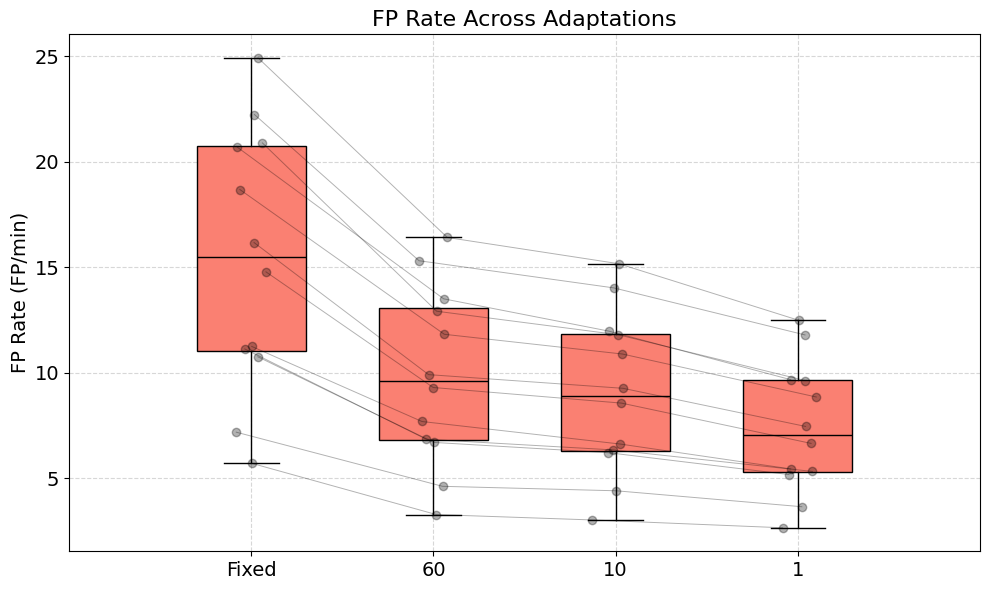

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'FP Rate Across Adaptations'}, ylabel='FP Rate (FP/min)'>)

In [5]:
plot_rates(all_results_df, "FP")

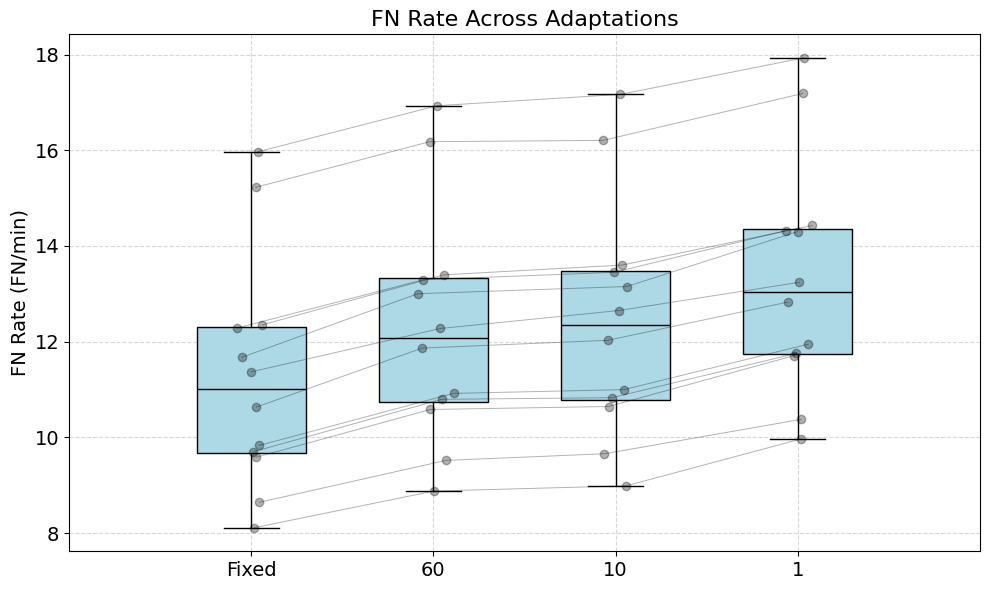

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'FN Rate Across Adaptations'}, ylabel='FN Rate (FN/min)'>)

In [6]:
plot_rates(all_results_df, "FN")

In [104]:
def plot_both(df, metrics):
    # Adaptation order & labels
    adapt_order = [0, 120, 20, 2]
    adapt_labels = ["Fixed", "60", "10", "1"]
    adapt_colors = {"FP": "salmon", "FN": "lightblue"}

    fig, ax = plt.subplots(figsize=(10, 6))

    width = 0.5 # narrower so both fit in each group
    xtick_positions = []
    xtick_labels = []
    

    for i, a in enumerate(adapt_order):
        base_position = i * (len(metrics))
        for j, metric in enumerate(metrics):
            # Precompute the network-averaged rates
            df_net_avg = (
                df.groupby(["Network", "Adapt"])[f"{metric}_rate"]
                .mean()
                .reset_index()
            )
            pos = base_position + j * width
            # vals = df.loc[df["Adapt"] == a, f"{metric}_rate"]
            vals = df_net_avg.loc[df_net_avg["Adapt"] == a, f"{metric}_rate"]
            bplot = ax.boxplot(
                vals,
                positions=[pos],
                widths=width,
                patch_artist=True,
                showfliers=False,
                medianprops=dict(color='black')
            )
            for patch in bplot['boxes']:
                patch.set_facecolor(adapt_colors[metric])

        # Mark center of group for xtick
        group_center = base_position + (len(metrics)-1) * width / 2
        xtick_positions.append(group_center)
        xtick_labels.append(adapt_labels[i])

        # Light gray background for group
        ax.axvspan(
            group_center - width*1.2,
           group_center + width*1.2,
            color="lightgray", alpha=0.1
        )

    # Aesthetics
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=14)
    ax.set_ylabel("Rate (events/min)", fontsize=14)
    ax.set_title("FP and FN Rates Across Adaptations", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Legend
    handles = [
        plt.Line2D([0], [0], color=adapt_colors["FP"], lw=6, label="FP rate"),
        plt.Line2D([0], [0], color=adapt_colors["FN"], lw=6, label="FN rate")
    ]
    # ax.legend(handles=handles, fontsize=12, loc='upper right')

    plt.tight_layout()
    plt.show()
    return fig, ax

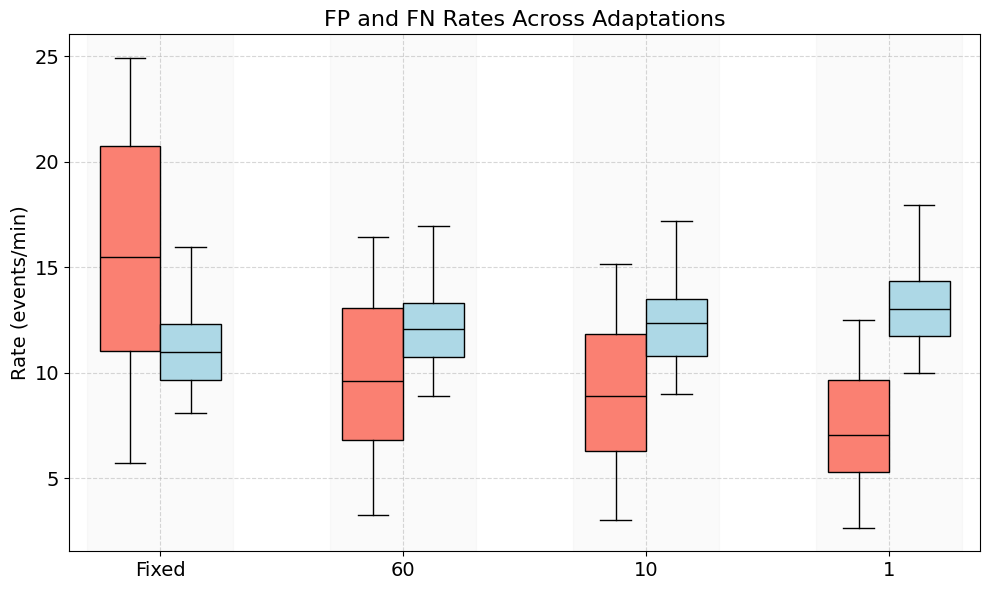

Saved plot to c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\eval\live_results\..\live_plots\fp_fn_rates.png


In [106]:
fig,ax=plot_both(all_results_df, ["FP", "FN"])
save_path = os.path.join(os.getcwd(), os.pardir, "live_plots", "fp_fn_rates.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import itertools
from matplotlib import cm
from matplotlib.patches import Patch
def holm_bonferroni(p_values, alpha=0.05):
    """Apply Holm–Bonferroni correction to a list of p-values."""
    m = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_pvals = np.array(p_values)[sorted_indices]
    reject = np.zeros(m, dtype=bool)
    adjusted_pvals = np.zeros(m)

    for k, p in enumerate(sorted_pvals):
        threshold = alpha / (m - k)
        if p <= threshold:
            reject[sorted_indices[k]] = True
        adjusted_pvals[sorted_indices[k]] = min(p * (m - k), 1.0)

    return adjusted_pvals, reject


def plot_metrics_by_adapt(df, metrics, adapt_order=[0,120,20,2], adapt_labels=["Fixed","60","10","1"]):
    n_adapt = len(adapt_order)
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, n_adapt))

    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.7
    spacing = 1 # gap between metric groups
    positions, data, plot_colors = [], [], []
    xticks, xtick_labels = [], []
    adapt_colors = {"FP":"salmon"
                    ,"FN":"lightblue",}
    # Before the loop over metrics, aggregate by network
    # df_avg = df.groupby(['Network','Adapt'])[ [f"{metric}_rate" for metric in metrics] ].mean().reset_index()

    # Collect positions and data per metric group
    for m_idx, metric in enumerate(metrics):
        base_pos = m_idx * (n_adapt + spacing)
        for a_idx, a in enumerate(adapt_order):
            vals = df[df['Adapt'] == a][f"{metric}_rate"].dropna().values
            # vals = df_avg[df_avg['Adapt'] == a][f"{metric}_rate"].dropna().values
            print(len(vals))
            pos = base_pos + a_idx
            positions.append(pos)
            data.append(vals)
            plot_colors.append(colors[a_idx])

        # Center tick per group
        xticks.append(base_pos + (n_adapt-1)/2)
        xtick_labels.append(metric)
        # Correct axvspan: span slightly before first and after last box
        span_start = base_pos - width*0.7
        span_end = base_pos + (n_adapt - 1) + width*0.7
        ax.axvspan(span_start, span_end, color=adapt_colors.get(metric,"lightgray"), alpha=0.2)

    # Draw boxplots
    box_heights = []
    for pos, vals, c in zip(positions, data, plot_colors):
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)
        box_heights.append(np.percentile(vals, 75) if len(vals) > 0 else 0)

    # Statistical tests per metric
    for m_idx, metric in enumerate(metrics):
        print(f"{metric}_rate")
        group_indices = range(m_idx * n_adapt, (m_idx+1) * n_adapt)
        group_data = [data[k] for k in group_indices]
        group_pos = [positions[k] for k in group_indices]
        group_heights = [box_heights[k] for k in group_indices]

        # All pairwise comparisons
        comparisons = list(itertools.combinations(range(n_adapt), 2))
        p_values = []
        for idx_a, idx_b in comparisons:
            set_a, set_b = group_data[idx_a], group_data[idx_b]
            if len(set_a)>0 and len(set_b)>0:
                _, p = wilcoxon(set_a, set_b)
            else:
                p = 1.0
            p_values.append(p)

        # Holm-Bonferroni
        adj_pvals, _ = holm_bonferroni(p_values)

            # Annotate brackets
        annotation_levels = np.zeros(n_adapt)
        for (idx_a, idx_b), adj_p in zip(comparisons, adj_pvals):
            level = max(annotation_levels[idx_a], annotation_levels[idx_b])
            
            # heights_for_bracket must include all boxes
            heights_for_bracket = np.array(group_heights) + 0.02*annotation_levels
            
            # barplot_annotate_brackets(idx_a, idx_b, adj_p, group_pos, heights_for_bracket, ax, dh=0.01, barh=0.0)
         
            print(f"Significant difference between Adapt {adapt_labels[idx_a]} and {adapt_labels[idx_b]}: p={adj_p:.4e}")

            if adj_p < 0.05:
                annotation_levels[idx_a] = annotation_levels[idx_b] = level + 1


    # Formatting
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=14)
    ax.tick_params(axis='y', which='major', labelsize=14)
    ax.set_ylabel("Rate (events/min)", fontsize=14)
    ax.set_title("FP and FN Rates Across Adaptations", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Legend for adaptations
    # legend_handles = [Patch(facecolor=colors[i], label=adapt_labels[i]) for i in range(n_adapt)]
    # ax.legend(handles=legend_handles, title="Adaptation", fontsize=12, loc='upper right')

    plt.tight_layout()
    return fig, ax

384
384
384
384
384
384
384
384
FP_rate
Significant difference between Adapt Fixed and 60: p=3.1111e-40
Significant difference between Adapt Fixed and 10: p=3.7158e-50
Significant difference between Adapt Fixed and 1: p=9.9084e-57
Significant difference between Adapt 60 and 10: p=3.7797e-18
Significant difference between Adapt 60 and 1: p=2.4447e-54
Significant difference between Adapt 10 and 1: p=1.9639e-40
FN_rate
Significant difference between Adapt Fixed and 60: p=1.7430e-28
Significant difference between Adapt Fixed and 10: p=2.8514e-36
Significant difference between Adapt Fixed and 1: p=1.5018e-49
Significant difference between Adapt 60 and 10: p=7.2440e-02
Significant difference between Adapt 60 and 1: p=1.2173e-28
Significant difference between Adapt 10 and 1: p=3.9820e-23


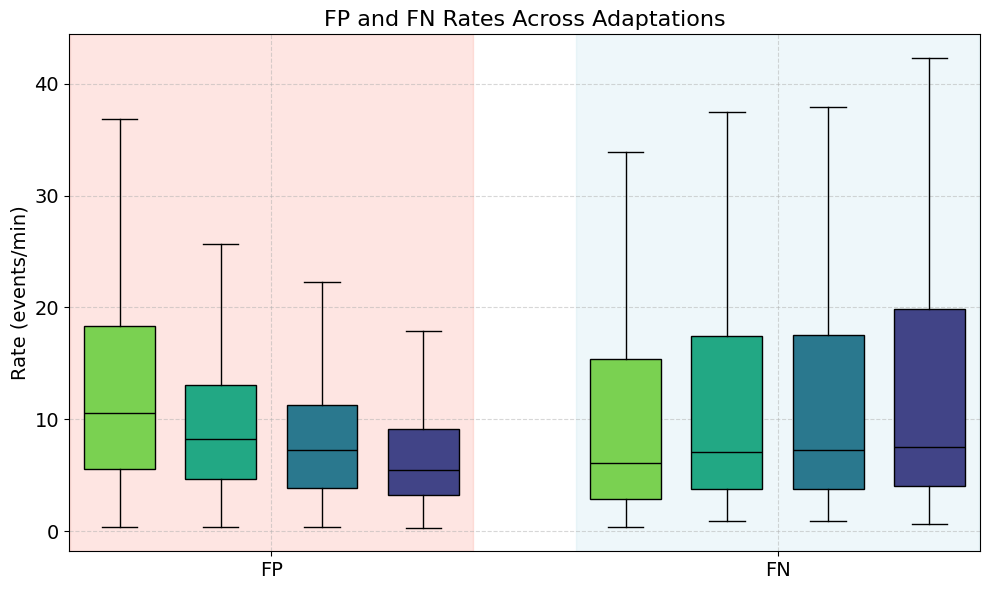

In [76]:
fig,ax=plot_metrics_by_adapt(all_results_df, ["FP", "FN"])
fig.savefig(os.path.join(os.getcwd(), os.pardir, "live_plots", "fp_fn_rates_by_adapt_together.png"), dpi=300, bbox_inches='tight')

In [73]:
def plot_metrics_by_adapt(df, metrics, adapt_order=[0,120,20,2], adapt_labels=["Fixed","60","10","1"]):
    n_adapt = len(adapt_order)
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, n_adapt))

    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.7
    spacing = 1  # gap between metric groups
    positions, data, plot_colors = [], [], []
    xticks, xtick_labels = [], []
    adapt_colors = {"FP":"salmon", "FN":"lightblue"}

    # Precompute network-averaged values for each metric
    df_avg_list = []
    for metric in metrics:
        df_avg_metric = df.groupby(['Network','Adapt'])[[f"{metric}_rate"]].mean().reset_index()
        df_avg_list.append(df_avg_metric)

    # Collect positions and data per metric group
    for m_idx, metric in enumerate(metrics):
        df_avg_metric = df_avg_list[m_idx]
        base_pos = m_idx * (n_adapt + spacing)
        for a_idx, a in enumerate(adapt_order):
            vals = df_avg_metric[df_avg_metric['Adapt'] == a][f"{metric}_rate"].dropna().values
            pos = base_pos + a_idx
            positions.append(pos)
            data.append(vals)
            plot_colors.append(colors[a_idx])

        # Center tick per group
        xticks.append(base_pos + (n_adapt-1)/2)
        xtick_labels.append(metric)
        # Correct axvspan: span slightly before first and after last box
        span_start = base_pos - width*0.7
        span_end = base_pos + (n_adapt - 1) + width*0.7
        ax.axvspan(span_start, span_end, color=adapt_colors.get(metric,"lightgray"), alpha=0.2)

    # Draw boxplots
    box_heights = []
    for pos, vals, c in zip(positions, data, plot_colors):
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)
        box_heights.append(np.percentile(vals, 75) if len(vals) > 0 else 0)

    #Loop over metrics
    for m_idx, metric in enumerate(metrics):
        print(f"{metric}_rate")
        df_avg_metric = df.groupby(['Network','Adapt'])[[f"{metric}_rate"]].mean().reset_index()
        print(df.groupby(['Network','Adapt'])[[f"{metric}_rate"]].mean().reset_index())
        # Collect metric-specific data
        group_data = []
        group_pos = []
        group_heights = []
        base_pos = m_idx * (n_adapt + spacing)
        
        for a_idx, a in enumerate(adapt_order):
            vals = df_avg_metric[df_avg_metric['Adapt'] == a][f"{metric}_rate"].dropna().values
            pos = base_pos + a_idx
            group_data.append(vals)
            group_pos.append(pos)
            group_heights.append(np.percentile(vals, 75) if len(vals) > 0 else 0)
        
        # All pairwise comparisons
        comparisons = list(itertools.combinations(range(n_adapt), 2))
        p_values = []
        for idx_a, idx_b in comparisons:
            set_a, set_b = group_data[idx_a], group_data[idx_b]
            if len(set_a) > 0 and len(set_b) > 0:
                _, p = wilcoxon(set_a, set_b)
            else:
                p = 1.0
            p_values.append(p)

        # Holm-Bonferroni correction
        adj_pvals, _ = holm_bonferroni(p_values)

        # Annotate brackets (levels)
        annotation_levels = np.zeros(n_adapt)
        for (idx_a, idx_b), adj_p in zip(comparisons, adj_pvals):
            level = max(annotation_levels[idx_a], annotation_levels[idx_b])
            heights_for_bracket = np.array(group_heights) + 0.02 * annotation_levels
            print(f"Significant difference between Adapt {adapt_labels[idx_a]} and {adapt_labels[idx_b]}: p={adj_p:.4e}")
            if adj_p < 0.05:
                annotation_levels[idx_a] = annotation_levels[idx_b] = level + 1

    # Formatting
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=14)
    ax.tick_params(axis='y', which='major', labelsize=14)
    ax.set_ylabel("Rate (events/min)", fontsize=14)
    ax.set_title("FP and FN Rates Across Adaptations", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Legend for adaptations
    # legend_handles = [Patch(facecolor=colors[i], label=adapt_labels[i]) for i in range(n_adapt)]
    # ax.legend(handles=legend_handles, title="Adaptation", fontsize=12, loc='upper right')

    plt.tight_layout()
    return fig, ax

FP_rate
                    Network  Adapt    FP_rate
0                adapt20_3b      0  24.915533
1                adapt20_3b      2  12.478605
2                adapt20_3b     20  15.160653
3                adapt20_3b    120  16.403954
4   dsb4updn_median_200_11b      0  18.675706
5   dsb4updn_median_200_11b      2   8.846598
6   dsb4updn_median_200_11b     20  10.882707
7   dsb4updn_median_200_11b    120  11.816965
8   dsb4updn_median_200_11f      0  14.774689
9   dsb4updn_median_200_11f      2   6.648302
10  dsb4updn_median_200_11f     20   8.557337
11  dsb4updn_median_200_11f    120   9.296192
12  dsb4updn_median_200_12b      0   5.699134
13  dsb4updn_median_200_12b      2   2.650110
14  dsb4updn_median_200_12b     20   3.021263
15  dsb4updn_median_200_12b    120   3.276033
16  dsb4updn_median_200_13f      0  16.163540
17  dsb4updn_median_200_13f      2   7.451658
18  dsb4updn_median_200_13f     20   9.258156
19  dsb4updn_median_200_13f    120   9.906338
20  dsb4updn_median_200_14

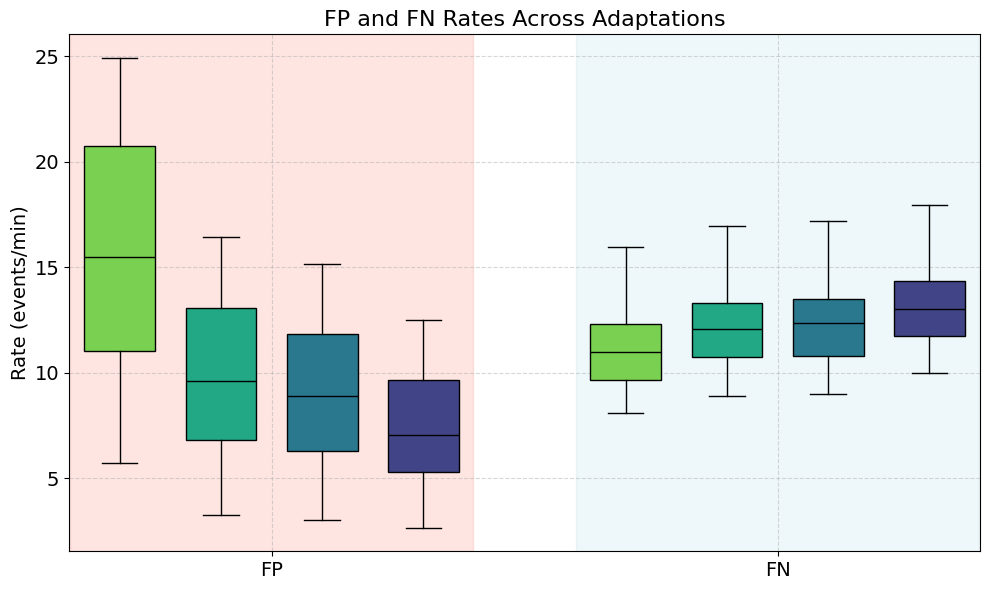

In [74]:
fig,ax=plot_metrics_by_adapt(all_results_df, ["FP", "FN"])

In [24]:
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
import pandas as pd
import statsmodels.stats.multitest as smm

def compare_adaptations(df, metric, adapt_order=[0, 120, 20, 2]):
    """
    Compare metric values across adaptations using Friedman + Wilcoxon + Bonferroni.
    
    df: DataFrame containing 'Adapt', 'Dataset', 'Channel', and metric column.
    metric: str, name of the column to compare (e.g., 'FP_rate' or 'FN_rate').
    adapt_order: list, order of adaptations to compare.
    """
    # Pivot so each row is a unique Dataset/Channel pair, columns are adaptations
    pivot_df = df.pivot_table(
        index=["Dataset", "Channel"], 
        columns="Adapt", 
        values=metric
    )[adapt_order]

    # Drop any rows with NaN (shouldn't happen if data is complete)
    pivot_df = pivot_df.dropna()

    # --- Friedman test ---
    friedman_stat, friedman_p = friedmanchisquare(*[pivot_df[a] for a in adapt_order])
    print(f"Friedman test: chi2 = {friedman_stat:.3f}, p = {friedman_p:.3e}")

    # --- Pairwise Wilcoxon tests ---
    pairs = list(combinations(adapt_order, 2))
    pvals = []
    stats_list = []
    for a1, a2 in pairs:
        stat, p = wilcoxon(pivot_df[a1], pivot_df[a2])
        pvals.append(p)
        stats_list.append({"Adapt1": a1, "Adapt2": a2, "stat": stat, "p_uncorrected": p})

    # --- Bonferroni correction ---
    reject, pvals_corrected, _, _ = smm.multipletests(pvals, alpha=0.05, method='bonferroni')

    # Add corrected p-values to results table
    for i, (p_corr, rj) in enumerate(zip(pvals_corrected, reject)):
        stats_list[i]["p_corrected"] = p_corr
        stats_list[i]["significant"] = rj

    results_df = pd.DataFrame(stats_list)
    return results_df


In [25]:
pivot_fp = compare_adaptations(all_results_df, "FP_rate")
pivot_fn = compare_adaptations(all_results_df, "FN_rate")

Friedman test: chi2 = 69.712, p = 4.918e-15
Friedman test: chi2 = 45.492, p = 7.272e-10


In [26]:
pivot_fp

,Adapt1,Adapt2,stat,p_uncorrected,p_corrected,significant
0,0,120,38.0,3.061257e-06,1.836754e-05,True
1,0,20,17.0,9.639189e-08,5.783513e-07,True
2,0,2,10.0,2.002344e-08,1.201406e-07,True
3,120,20,67.0,9.054644e-05,5.432786e-04,True
4,120,2,3.0,2.328306e-09,1.396984e-08,True
5,20,2,12.0,3.259629e-08,1.955777e-07,True


In [27]:
pivot_fn

,Adapt1,Adapt2,stat,p_uncorrected,p_corrected,significant
0,0,120,46.5,8.747913e-06,5.248748e-05,True
1,0,20,28.0,1.623417e-05,9.740499e-05,True
2,0,2,3.0,2.328306e-09,1.396984e-08,True
3,120,20,226.5,4.883263e-01,1.000000e+00,False
4,120,2,51.0,1.131034e-04,6.786202e-04,True
5,20,2,72.0,5.626835e-04,3.376101e-03,True


In [ ]:
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
import pandas as pd
import statsmodels.stats.multitest as smm

def compare_adaptations(df, metric, adapt_order=[0, 120, 20, 2]):
    """
    Compare metric values across adaptations using Friedman + Wilcoxon + Bonferroni.
    
    df: DataFrame containing 'Adapt', 'Dataset', 'Channel', and metric column.
    metric: str, name of the column to compare (e.g., 'FP_rate' or 'FN_rate').
    adapt_order: list, order of adaptations to compare.
    """
    # Pivot so each row is a unique Dataset/Channel pair, columns are adaptations
    pivot_df = df.pivot_table(
        index=["Dataset", "Channel"], 
        columns="Adapt", 
        values=metric
    )[adapt_order]

    # Drop any rows with NaN (shouldn't happen if data is complete)
    pivot_df = pivot_df.dropna()

    # --- Friedman test ---
    friedman_stat, friedman_p = friedmanchisquare(*[pivot_df[a] for a in adapt_order])
    print(f"Friedman test: chi2 = {friedman_stat:.3f}, p = {friedman_p:.3e}")

    # --- Pairwise Wilcoxon tests ---
    pairs = list(combinations(adapt_order, 2))
    pvals = []
    stats_list = []
    for a1, a2 in pairs:
        stat, p = wilcoxon(pivot_df[a1], pivot_df[a2])
        pvals.append(p)
        stats_list.append({"Adapt1": a1, "Adapt2": a2, "stat": stat, "p_uncorrected": p})

    # --- Bonferroni correction ---
    reject, pvals_corrected, _, _ = smm.multipletests(pvals, alpha=0.05, method='bonferroni')

    # Add corrected p-values to results table
    for i, (p_corr, rj) in enumerate(zip(pvals_corrected, reject)):
        stats_list[i]["p_corrected"] = p_corr
        stats_list[i]["significant"] = rj

    results_df = pd.DataFrame(stats_list)
    return results_df


In [51]:
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
import pandas as pd
import statsmodels.stats.multitest as smm

def compare_adaptations_network_avg(df, metric, adapt_order=[0, 120, 20, 2]):
    """
    Compare network-averaged metric values across adaptations 
    using Friedman + Wilcoxon + Bonferroni correction.
    
    df: DataFrame containing 'Adapt', 'Network', and metric column.
    metric: str, name of the column to compare (e.g., 'FP_rate' or 'FN_rate').
    adapt_order: list, order of adaptations to compare.
    """

    # --- Average over networks ---
    net_avg_df = (
        df.groupby(["Network", "Adapt"])[metric]
        .mean()
        .reset_index()
    )

    # --- Pivot so each row = one network, columns = adaptations ---
    pivot_df = net_avg_df.pivot_table(
        index="Network",
        columns="Adapt",
        values=metric
    )[adapt_order]

    # Drop missing values
    pivot_df = pivot_df.dropna()

    # --- Friedman test ---
    friedman_stat, friedman_p = friedmanchisquare(*[pivot_df[a] for a in adapt_order])
    print(f"Friedman test: chi2 = {friedman_stat:.3f}, p = {friedman_p:.3e}")

    # --- Pairwise Wilcoxon tests ---
    pairs = list(combinations(adapt_order, 2))
    pvals = []
    stats_list = []

    for a1, a2 in pairs:
        stat, p = wilcoxon(pivot_df[a1], pivot_df[a2])
        pvals.append(p)
        stats_list.append({
            "Adapt1": a1,
            "Adapt2": a2,
            "stat": stat,
            "p_uncorrected": p
        })

    # --- Bonferroni correction ---
    reject, pvals_corrected, _, _ = smm.multipletests(
        pvals, alpha=0.05, method='bonferroni'
    )

    for i, (p_corr, rj) in enumerate(zip(pvals_corrected, reject)):
        stats_list[i]["p_corrected"] = p_corr
        stats_list[i]["significant"] = rj

    results_df = pd.DataFrame(stats_list)
    return results_df


In [52]:
compare_adaptations_network_avg(all_results_df, "FP_rate")

Friedman test: chi2 = 36.000, p = 7.488e-08


,Adapt1,Adapt2,stat,p_uncorrected,p_corrected,significant
0,0,120,0.0,0.000488,0.00293,True
1,0,20,0.0,0.000488,0.00293,True
2,0,2,0.0,0.000488,0.00293,True
3,120,20,0.0,0.000488,0.00293,True
4,120,2,0.0,0.000488,0.00293,True
5,20,2,0.0,0.000488,0.00293,True


In [53]:
compare_adaptations_network_avg(all_results_df, "FN_rate")

Friedman test: chi2 = 36.000, p = 7.488e-08


,Adapt1,Adapt2,stat,p_uncorrected,p_corrected,significant
0,0,120,0.0,0.000488,0.00293,True
1,0,20,0.0,0.000488,0.00293,True
2,0,2,0.0,0.000488,0.00293,True
3,120,20,0.0,0.000488,0.00293,True
4,120,2,0.0,0.000488,0.00293,True
5,20,2,0.0,0.000488,0.00293,True


In [ ]:
import numpy as np
from itertools import combinations
from scipy.stats import wilcoxon

adapt_order = [0, 120, 20, 2]
metric= "FN"  # or "FN", depending on what you want to analyze
# compute network averages (same as in your function)
net_avg_df = all_results_df.groupby(["Network", "Adapt"])[f"{metric}_rate"].mean().reset_index()
pivot = net_avg_df.pivot(index="Network", columns="Adapt", values=f"{metric}_rate")[adapt_order].dropna()
print("Pivot (network averages):")
print(pivot.head())
for a in adapt_order:
    print(f"Adapt {a} mean {metric} rate: {pivot[a].mean():.3f}")
    print(f"adapt{a} median {metric} rate: {pivot[a].median():.3f}")
# pairwise sign summary + wilcoxon check
for a1, a2 in combinations(adapt_order, 2):
    diffs = pivot[a2] - pivot[a1]   # positive means Adapt a2 > a1
    mean_diff = diffs.mean()
    percentual_change = (mean_diff / pivot[a1].mean()) * 100
    print(f"{a1} vs {a2}: mean diff = {mean_diff:.3f} ({percentual_change:.2f}%)")


Pivot (network averages):
Adapt                          0          120        20         2  
Network                                                            
adapt20_3b                8.110759   8.877649   8.987359   9.967181
dsb4updn_median_200_11b   9.832678  10.919531  10.997847  11.946269
dsb4updn_median_200_11f  11.368643  12.275615  12.650802  13.240225
dsb4updn_median_200_12b  15.967324  16.931459  17.166967  17.931401
dsb4updn_median_200_13f  10.632634  11.865844  12.028850  12.826795
Adapt 0 mean FN rate: 11.281
adapt0 median FN rate: 11.001
Adapt 120 mean FN rate: 12.303
adapt120 median FN rate: 12.071
Adapt 20 mean FN rate: 12.448
adapt20 median FN rate: 12.340
Adapt 2 mean FN rate: 13.332
adapt2 median FN rate: 13.034
0 vs 120: mean diff = 1.022 (9.06%)
0 vs 20: mean diff = 1.166 (10.34%)
0 vs 2: mean diff = 2.051 (18.18%)
120 vs 20: mean diff = 0.144 (1.17%)
120 vs 2: mean diff = 1.029 (8.36%)
20 vs 2: mean diff = 0.885 (7.11%)


: 

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def plot_relative_change(df, metric, percent=False): 
    adapt_order = [0, 120, 20, 2]
    adapt_labels = ["Fixed", "60", "10", "1"]
    adapt_colors = {"FP": "salmon", "FN": "lightblue"}

    # Network-averaged rates
    df_net_avg = (
        df.groupby(["Network", "Adapt"])[f"{metric}_rate"]
        .mean()
        .reset_index()
    )

    # Compute relative change per network
    df_rel = []
    for net, subdf in df_net_avg.groupby("Network"):
        subdf = subdf.set_index("Adapt").loc[adapt_order]
        baseline = subdf.loc[0, f"{metric}_rate"]
        if percent:
            subdf[f"{metric}_rel"] = (subdf[f"{metric}_rate"] - baseline) / baseline * 100
        else:
            subdf[f"{metric}_rel"] = subdf[f"{metric}_rate"] - baseline
        df_rel.append(subdf.reset_index().assign(Network=net))
    df_rel = pd.concat(df_rel, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.6
    positions = list(range(len(adapt_order)))

    for i, a in enumerate(adapt_order):
        vals = df_rel.loc[df_rel["Adapt"] == a, f"{metric}_rel"]
        bplot = ax.boxplot(
            vals,
            positions=[positions[i]],
            widths=width,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black')
        )
        for patch in bplot['boxes']:
            patch.set_facecolor(adapt_colors[metric])

    # Overlay paired lines
    for net, subdf in df_rel.groupby("Network"):
        subdf_sorted = subdf.set_index("Adapt").loc[adapt_order].reset_index()
        jitter = np.random.normal(0, 0.05, size=len(subdf_sorted))
        pos = np.array(positions) + jitter
        ax.plot(
            pos,
            subdf_sorted[f"{metric}_rel"].values,
            marker='o',
            color="black",
            alpha=0.3,
            linewidth=0.7
        )

    # Aesthetics
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(positions)
    ax.set_xticklabels(adapt_labels, fontsize=14)
    ylabel = f"Relative Change in {metric} Rate"
    if percent:
        ylabel += " (%)"
    else:
        ylabel += f" ({metric}/min)"
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(f"Change in {metric} Rate Relative to Fixed", fontsize=16)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(adapt_order))

    plt.tight_layout()
    plt.show()
    return fig, ax


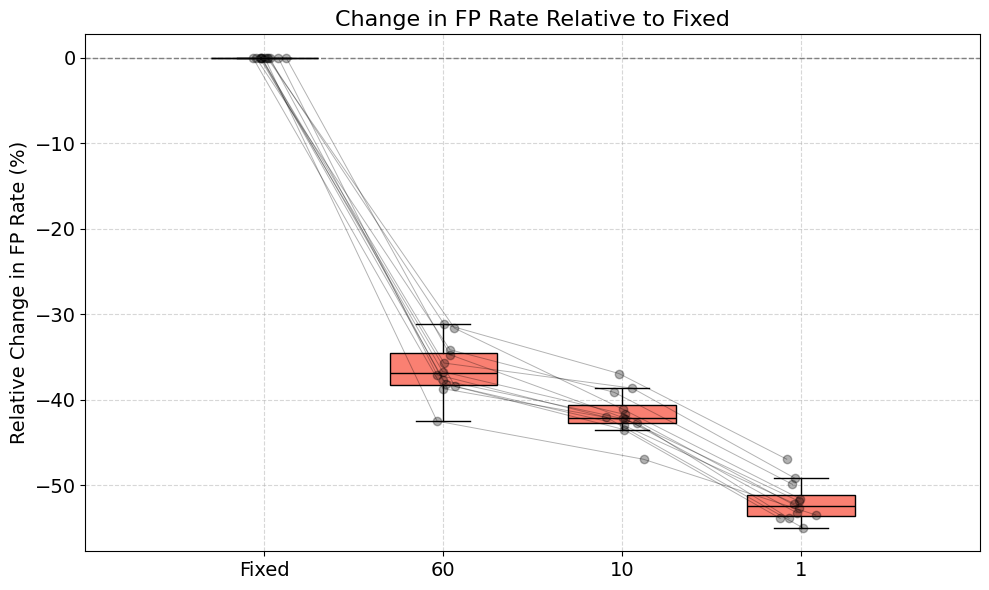

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Change in FP Rate Relative to Fixed'}, ylabel='Relative Change in FP Rate (%)'>)

In [64]:
# plot_rates(all_results_df, "FP")
plot_relative_change(all_results_df, "FP", percent=True)

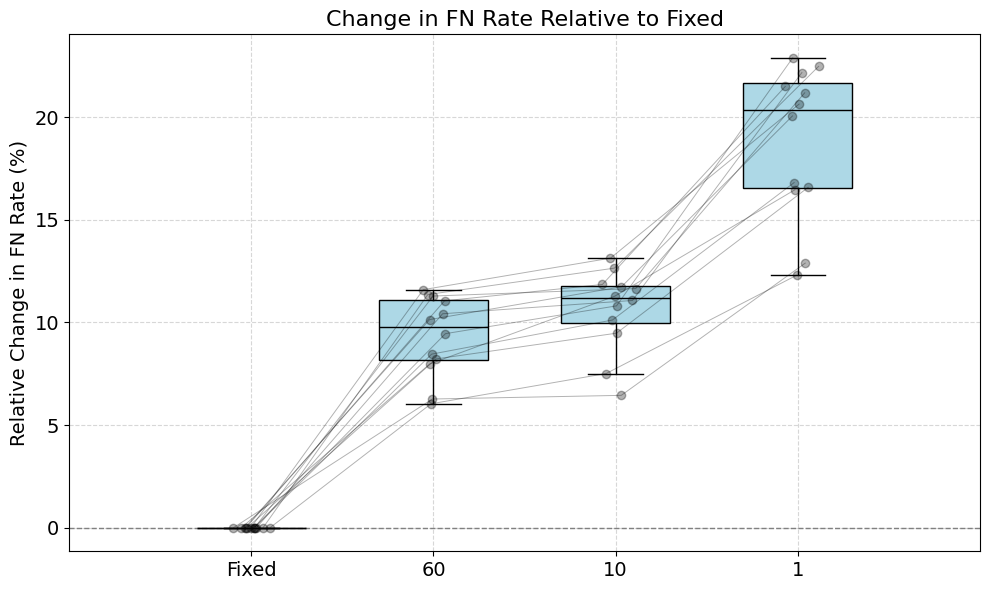

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Change in FN Rate Relative to Fixed'}, ylabel='Relative Change in FN Rate (%)'>)

In [65]:
plot_relative_change(all_results_df, "FN", percent=True)

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_relative_change(df, metric, group_level="Channel", percent=False):
    """
    Plot relative change in metric rate compared to baseline adaptation (Fixed = 0).

    Parameters
    ----------
    df : pd.DataFrame
        Must contain 'Network', 'Dataset', 'Channel', 'Adapt', and f"{metric}_rate".
    metric : str
        Metric name without "_rate" suffix (e.g., "FP", "FN").
    group_level : str
        One of "Channel", "Dataset", or "Network".
    percent : bool
        If True, change is in percent; else absolute.
    """
    adapt_order = [0, 120, 20, 2]
    adapt_labels = ["Fixed", "60", "10", "1"]
    adapt_colors = {"FP": "salmon", "FN": "lightblue"}

    # Decide grouping columns
    if group_level == "Channel":
        group_cols = ["Network", "Dataset", "Channel", "Adapt"]
    elif group_level == "Dataset":
        group_cols = ["Network", "Dataset", "Adapt"]
    elif group_level == "Network":
        group_cols = ["Network", "Adapt"]
    else:
        raise ValueError("group_level must be 'Channel', 'Dataset', or 'Network'.")

    # Aggregate rates at desired level
    df_grouped = (
        df.groupby(group_cols)[f"{metric}_rate"]
        .mean()
        .reset_index()
    )

    # Compute relative change per group
    df_rel = []
    id_cols = group_cols[:-1]  # everything except "Adapt"
    for _, subdf in df_grouped.groupby(id_cols):
        subdf = subdf.set_index("Adapt").loc[adapt_order]
        baseline = subdf.loc[0, f"{metric}_rate"]
        if percent:
            subdf[f"{metric}_rel"] = (subdf[f"{metric}_rate"] - baseline) / baseline * 100
        else:
            subdf[f"{metric}_rel"] = subdf[f"{metric}_rate"] - baseline
        df_rel.append(subdf.reset_index().assign(**dict(zip(id_cols, _ if isinstance(_, tuple) else (_ ,)))))
    df_rel = pd.concat(df_rel, ignore_index=True)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.6
    positions = list(range(len(adapt_order)))

    # Boxplots
    for i, a in enumerate(adapt_order):
        vals = df_rel.loc[df_rel["Adapt"] == a, f"{metric}_rel"]
        bplot = ax.boxplot(
            vals,
            positions=[positions[i]],
            widths=width,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black')
        )
        for patch in bplot['boxes']:
            patch.set_facecolor(adapt_colors[metric])

    # Overlay paired lines for each group
    for _, subdf in df_rel.groupby(id_cols):
        subdf_sorted = subdf.set_index("Adapt").loc[adapt_order].reset_index()
        jitter = np.random.normal(0, 0.05, size=len(subdf_sorted))
        pos = np.array(positions) + jitter
        ax.plot(
            pos,
            subdf_sorted[f"{metric}_rel"].values,
            marker='o',
            color="black",
            alpha=0.3,
            linewidth=0.7
        )

    # Aesthetics
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(positions)
    ax.set_xticklabels(adapt_labels, fontsize=14)
    ylabel = f"Relative Change in {metric} Rate"
    ylabel += " (%)" if percent else f" ({metric}/min)"
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(f"Change in {metric} Rate per {group_level} Relative to Fixed", fontsize=16)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(adapt_order))

    plt.tight_layout()
    plt.show()
    return fig, ax


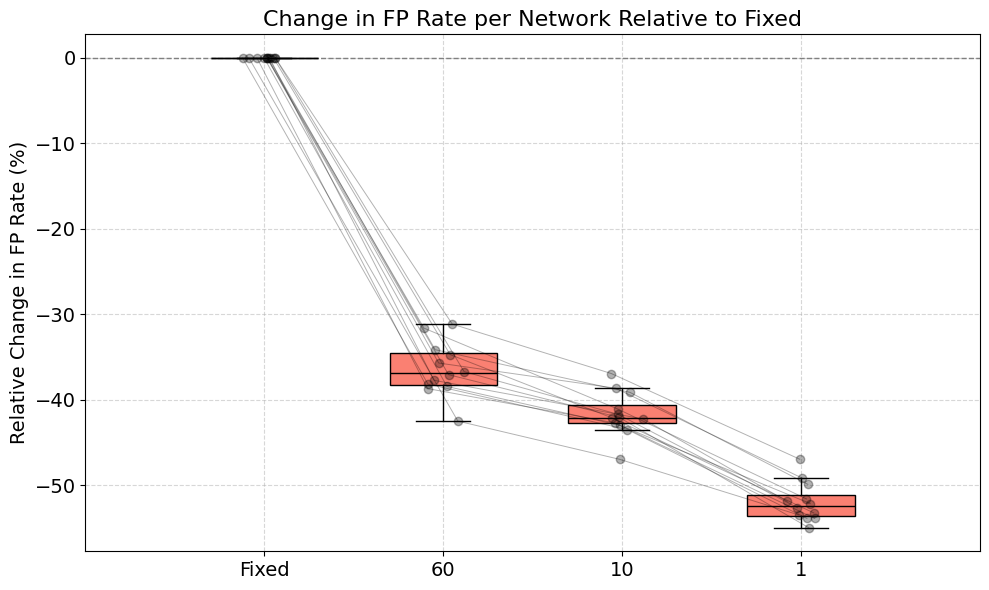

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Change in FP Rate per Network Relative to Fixed'}, ylabel='Relative Change in FP Rate (%)'>)

In [78]:
# Per channel
plot_relative_change(all_results_df, "FP", group_level="Network",percent=True)


In [90]:
def plot_relative_change_together(df, metrics, group_level="Channel", percent=False):
    adapt_order = [0, 120, 20, 2]
    adapt_labels = ["Fixed", "60", "10", "1"]
    adapt_colors = {"FP": "salmon", "FN": "lightblue"}

    # Decide grouping columns
    if group_level == "Channel":
        group_cols = ["Network", "Dataset", "Channel", "Adapt"]
    elif group_level == "Dataset":
        group_cols = ["Network", "Dataset", "Adapt"]
    elif group_level == "Network":
        group_cols = ["Network", "Adapt"]
    else:
        raise ValueError("group_level must be 'Channel', 'Dataset', or 'Network'.")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.6
    positions = list(range(len(adapt_order)))

    for metric in metrics:
        # Aggregate rates at desired level
        df_grouped = (
            df.groupby(group_cols)[f"{metric}_rate"]
            .mean()
            .reset_index()
        )

        # Compute relative change per group
        df_rel = []
        id_cols = group_cols[:-1]  # everything except "Adapt"
        for _, subdf in df_grouped.groupby(id_cols):
            subdf = subdf.set_index("Adapt").loc[adapt_order]
            baseline = subdf.loc[0, f"{metric}_rate"]
            if percent:
                subdf[f"{metric}_rel"] = (subdf[f"{metric}_rate"] - baseline) / baseline * 100
            else:
                subdf[f"{metric}_rel"] = subdf[f"{metric}_rate"] - baseline
            df_rel.append(subdf.reset_index().assign(**dict(zip(id_cols, _ if isinstance(_, tuple) else (_ ,)))))
        df_rel = pd.concat(df_rel, ignore_index=True)

        # Boxplots
        for i, a in enumerate(adapt_order):
            vals = df_rel.loc[df_rel["Adapt"] == a, f"{metric}_rel"]
            bplot = ax.boxplot(
                vals,
                positions=[positions[i]],
                widths=width,
                patch_artist=True,
                showfliers=False,
                medianprops=dict(color='black')
            )
            for patch in bplot['boxes']:
                patch.set_facecolor(adapt_colors[metric])

        # Overlay paired lines for each group
        for _, subdf in df_rel.groupby(id_cols):
            subdf_sorted = subdf.set_index("Adapt").loc[adapt_order].reset_index()
            jitter = np.random.normal(0, 0.05, size=len(subdf_sorted))
            pos = np.array(positions) + jitter
            ax.plot(
                pos,
                subdf_sorted[f"{metric}_rel"].values,
                marker='o',
                color="black",
                alpha=0.3,
                linewidth=0.7
            )
    
    # After loop: add legend manually
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=adapt_colors[m], label=m) for m in metrics]
    # ax.legend(handles=legend_handles, title="Metric")

    # Aesthetics
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(positions)
    ax.set_xticklabels(adapt_labels, fontsize=14)
    
    ylabel = "Relative Change in Rate"
    ylabel += " (%)" if percent else " (events/min)"
    ax.set_ylabel(ylabel, fontsize=14)
    
    ax.set_title(f"Change in Metrics Relative to Fixed ({group_level})", fontsize=16)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(adapt_order))

    plt.tight_layout()
    plt.show()
    return fig, ax


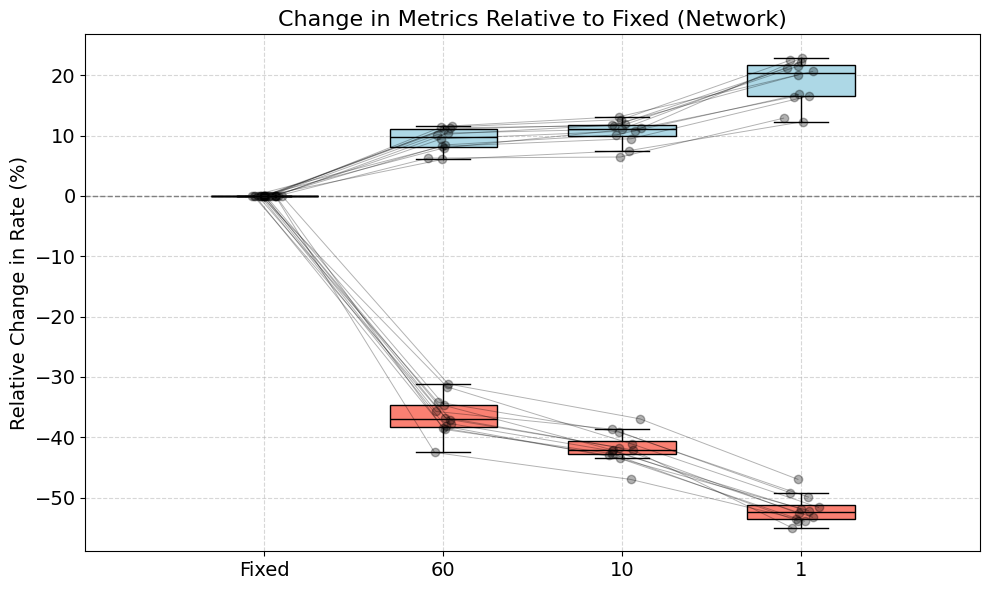

In [107]:
fig,ax=plot_relative_change_together(all_results_df, ["FP","FN"], percent=True, group_level="Network")
save_path = os.path.join(os.getcwd(),os.pardir,"live_plots","relative_change_plot.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight')